In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [3]:
import pandas as pd
from glob import glob
from tqdm import tqdm
from skimage import io

In [4]:
from skimage.transform import rotate, resize
from skimage.exposure import equalize_adapthist

In [5]:
path_images = './00.data/cropped_old/'
path_labels = './RotatedImageFiles.txt'

In [6]:
data_files = glob(path_images+'*')
data_files_zero = [path for path in data_files if '_0.jpg' in path]
data_labels = pd.read_csv(path_labels)

In [7]:
data_labels.index = data_labels.Filename.values

In [8]:
def get_image(img_path):
    
    img = io.imread(img_path)
    
    return(img)


def get_label(img_path,out=data_labels):
    
    img_id = img_path.split('/')[-1]
    row = out.loc[img_id]
    angle = row['Doppler_Angle']
    
    return(angle)

In [9]:
data_x = [get_image(path) for path in data_files]
data_y = [get_label(path) for path in data_files]

In [10]:
data_x_zero = [get_image(path) for path in data_files_zero]
data_y_zero = [get_label(path) for path in data_files_zero]

(82.3751, 30, 112.3751)


/home/npatil4/.local/lib/python2.7/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from float64 to uint16
  .format(dtypeobj_in, dtypeobj_out))


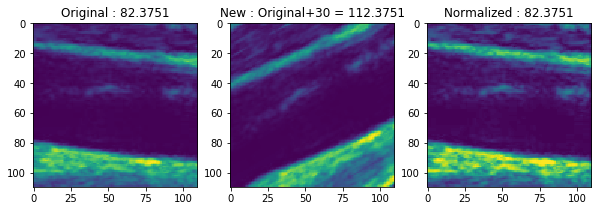

In [11]:
angle_set = np.arange(-30,35,5)
rotation_angle = np.random.choice(a = angle_set)
image_index = np.random.choice(np.arange(0,len(data_x_zero)))

img_x = data_x_zero[image_index]
img_y = data_y_zero[image_index]
new_angle = img_y+rotation_angle


img_x = resize(img_x,(110,110),mode='reflect')
img_rot = rotate(img_x,angle=rotation_angle,mode='reflect')


print(img_y,rotation_angle,new_angle)

plt.figure(figsize=(10,6))

plt.subplot(131)
plt.imshow(img_x,)
plt.title('Original : '+str(img_y));

plt.subplot(132)
plt.imshow(img_rot)
plt.title('New : Original'+'+'+str(rotation_angle)+' = '+str(new_angle));

plt.subplot(133)
plt.imshow(equalize_adapthist(img_x))
plt.title('Normalized : '+str(img_y));

86.458


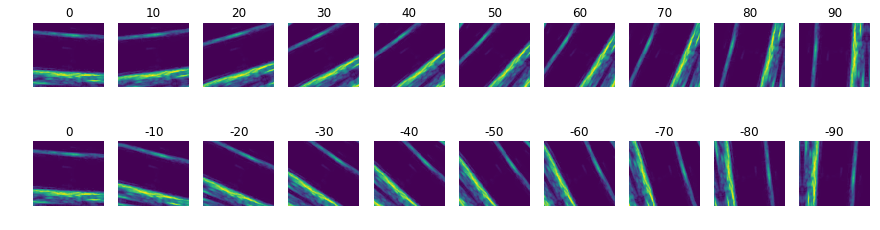

In [12]:
img_path = data_files_zero[0]
img_id = img_path.split('/')[-1]
img_zero = plt.imread(img_path)

img_cols = 10
rotation_step = 10

i = 1

print(data_labels.loc[img_id]['Doppler_Angle'])
plt.figure(figsize=(15,4))
for ix in range(img_cols):
    angle_pos = ix*rotation_step
    angle_neg = -1*ix*rotation_step
    
    img_rot01 = rotate(img_zero,angle=angle_pos,mode='reflect')
    img_rot02 = rotate(img_zero,angle=angle_neg,mode='reflect')
    
    plt.subplot(2,img_cols,i)
    plt.imshow(img_rot01)
    plt.title(angle_pos)
    plt.axis('off')
    
    plt.subplot(2,img_cols,i+img_cols)
    plt.imshow(img_rot02)
    plt.title(angle_neg)
    plt.axis('off');
    
    i+=1

In [13]:
def image_generator(input_data,
                    output_data,
                    batch_size=25,
                    img_channels=3,
                    rotation_range=60,
                    negative=False,
                    input_size=(100, 100),
                    equalize_hist=True):

    img_rows, img_cols = input_size

    while True:
        
        batch_files = np.random.choice(input_data, batch_size, replace=True)
        
        if negative:
            start_range = -1 * rotation_range
        else:
            start_range = 0
            
        angle_set = np.arange(start_range,rotation_range,5)
        
        batch_images = []
        batch_labels = []

        for current_file in batch_files:

            rotation_angle = np.random.choice(a = angle_set)
            current_image = get_image(img_path = current_file)
            
            current_label = get_label(img_path=current_file, out=output_data)
            new_angle = current_label+rotation_angle
            
            
            if equalize_hist:
                current_image = equalize_adapthist(image=current_image)
                
            if new_angle>180:
                new_angle-=180

            current_image = resize(image=current_image, output_shape=(img_rows,img_cols), mode='reflect')
            current_image = rotate(image=current_image, angle=rotation_angle, mode='reflect')
            
            batch_images.append(current_image)
            batch_labels.append(new_angle)

        batch_images = np.array(batch_images)
        batch_labels = np.array(batch_labels)
        
        batch_images = np.expand_dims(batch_images,-1)
        batch_labels = np.expand_dims(np.expand_dims(np.expand_dims(batch_labels,1),1),1)
        
        batch_x, batch_y = batch_images, batch_labels

        yield (batch_x, batch_y)

In [14]:
from keras import backend as K
from keras.models import Model
from keras.layers import Input, BatchNormalization, Conv2D, Dense, Activation, Dropout

/software/anaconda/5.0.1b/lib/python2.7/site-packages/h5py/__init__.py:34: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [15]:
img_size = (100,100,1)
dropout_rate = 0.25

In [16]:
from keras.regularizers import l2

In [17]:
dropout_rate

0.25

In [18]:
K.clear_session()

main_input = Input(shape=img_size)

x = BatchNormalization()(main_input)
x = Conv2D(filters=16, kernel_size=(8,8),kernel_regularizer=l2(l=0.1))(x)
x = Conv2D(filters=16, kernel_size=(8,8),kernel_regularizer=l2(l=0.1))(x)

x = BatchNormalization()(x)
x = Conv2D(filters=32, kernel_size=(6,6),strides=(2,2),kernel_regularizer=l2(0.1))(x)
x = Conv2D(filters=32, kernel_size=(6,6),strides=(2,2),kernel_regularizer=l2(0.1))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = BatchNormalization()(x)
x = Conv2D(filters=64, kernel_size=(4,4),strides=(2,2),kernel_regularizer=l2(0.1))(x)
x = Conv2D(filters=64, kernel_size=(4,4),strides=(2,2),kernel_regularizer=l2(0.1))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = BatchNormalization()(x)
x = Conv2D(filters=128, kernel_size=(2,2),strides=(1,1),kernel_regularizer=l2(0.1))(x)
x = Conv2D(filters=128, kernel_size=(2,2),strides=(1,1),kernel_regularizer=l2(0.1))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = Dense(units=1,kernel_regularizer=l2(l=0.1))(x)
main_output = Activation('relu')(x)

model = Model(inputs=[main_input], outputs=[main_output])

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 100, 100, 1)       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 100, 100, 1)       4         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 93, 93, 16)        1040      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 86, 86, 16)        16400     
_________________________________________________________________
batch_normalization_2 (Batch (None, 86, 86, 16)        64        
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 41, 41, 32)        18464     
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 18, 18, 32)        36896     
__________

In [19]:
train_generator = image_generator(data_files_zero[:-10],data_labels,rotation_range=60, negative=True)
test_generator = image_generator(data_files_zero[-10:],data_labels,rotation_range=60, negative=True)

In [20]:
from keras.callbacks import ModelCheckpoint,EarlyStopping

MC = ModelCheckpoint(filepath='./02.model/model_02.h5')
ES = EarlyStopping(patience=10)

model.compile(optimizer='adam',loss='mse')
model.fit_generator(generator=train_generator,
                    validation_data = test_generator,
                    callbacks=[MC,ES],
                    steps_per_epoch=100,
                    validation_steps=10,
                    epochs=100,
                    verbose=2)

In [21]:
from keras.models import load_model

model = load_model('./02.model/model_02.h5')

In [22]:
from tqdm import tqdm

In [23]:
def two_scales(ax1, x, data1, data2, c1, c2):
    """

    Parameters
    ----------
    ax : axis
        Axis to put two scales on

    x : array-like
        x-axis values for both datasets

    data1: array-like
        Data for left hand scale

    data2 : array-like
        Data for right hand scale

    c1 : color
        Color for line 1

    c2 : color
        Color for line 2

    Returns
    -------
    ax : axis
        Original axis
    ax2 : axis
        New twin axis
    """
    ax2 = ax1.twinx()

    ax1.scatter(x, data1, color=c1, alpha=0.5, s=10)
    ax1.set_xlabel('$Y$ ( Actual )')
    ax1.set_ylabel('$\hat{Y}$ ( Predicted)',rotation=0)

    ax2.scatter(x, data2, color=c2, alpha=0.5, s=5)
    ax2.set_ylabel('$\Delta$ ( Error )',rotation=0)
    return ax1, ax2

In [24]:
images_actual = []
y_actual = []
y_predicted = []

for i in tqdm(range(100)):
    
    x,y_real = test_generator.next()
    y_predict = model.predict_on_batch(x)
    
    images_actual+=[x]
    y_actual += [y_real]
    y_predicted += [y_predict]

images_actual = np.concatenate(images_actual)
y_real = np.concatenate(y_actual)
y_predicted = np.concatenate(y_predicted)

100%|██████████| 100/100 [01:11<00:00,  1.39it/s]


In [25]:
images_actual = np.squeeze(images_actual,axis=-1)
y_real = np.squeeze(np.squeeze(y_real,axis=-1))
y_predicted = np.squeeze(np.squeeze(y_predicted,axis=-1))

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

(0.9687216130184126, 6.2826857746963345)


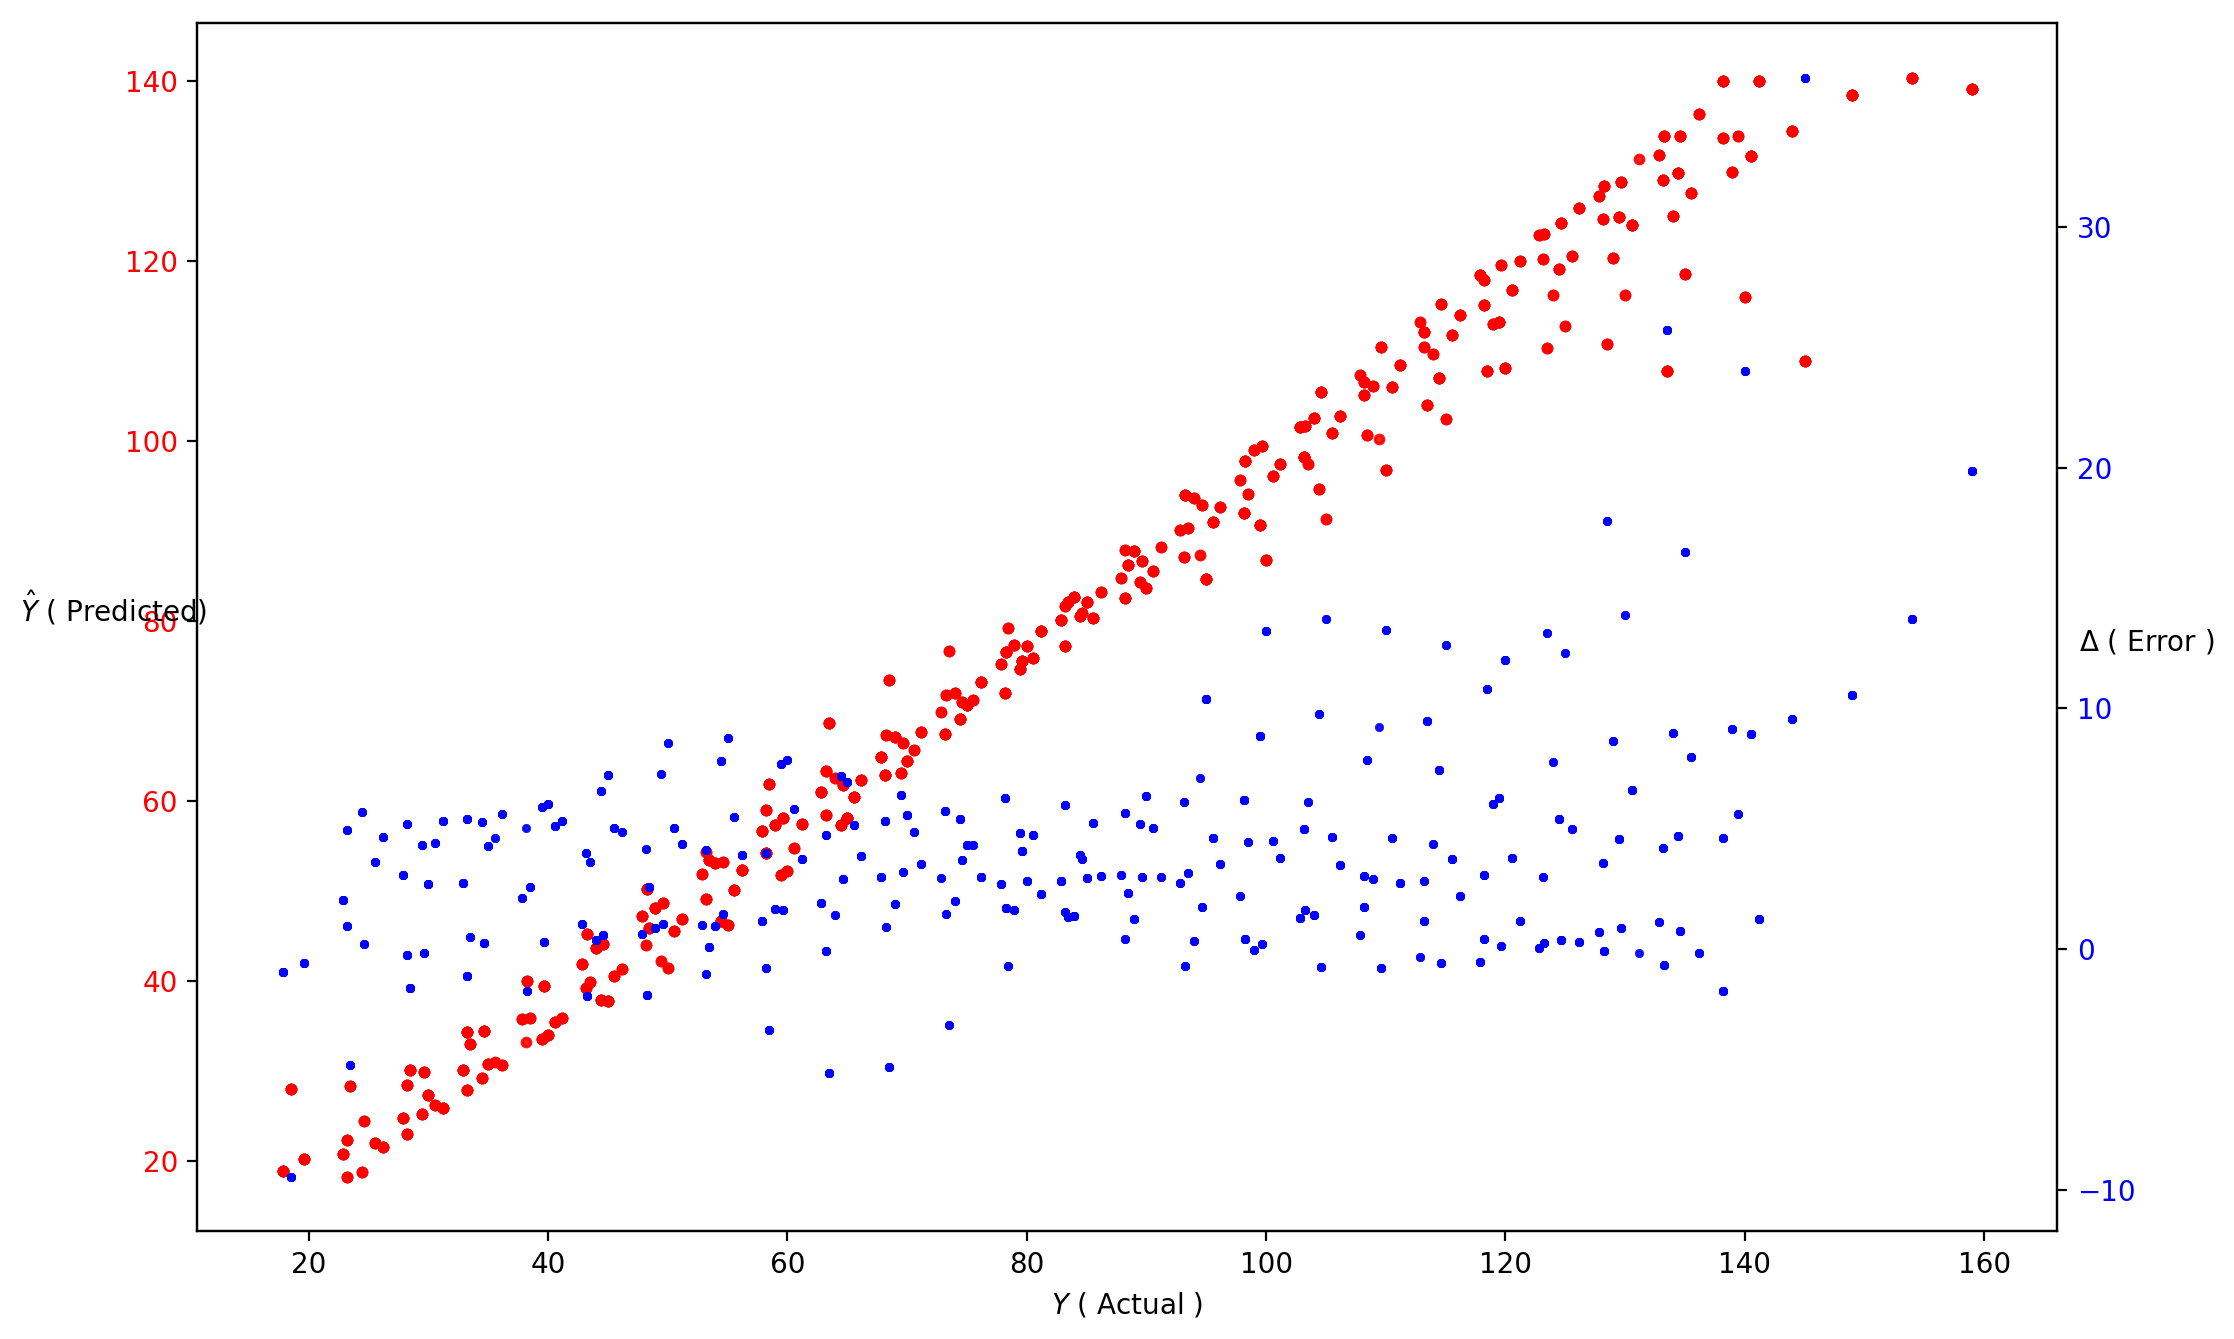

In [27]:
x_c = y_real
y_1 = y_predicted
y_2 = y_real-y_predicted

fig, ax = plt.subplots(figsize=(12,8), dpi=200)
ax1, ax2 = two_scales(ax1 = ax, 
                      x = x_c, 
                      data1 = y_1, 
                      data2 = y_2, 
                      c1 = 'r', 
                      c2 = 'b')


# Change color of each axis
def color_y_axis(ax, color):
    """Color your axes."""
    for t in ax.get_yticklabels():
        t.set_color(color)
    return None

print(
    r2_score(y_real, y_predicted),
    np.sqrt(mean_squared_error(y_real, y_predicted))
)

color_y_axis(ax1, 'r')
color_y_axis(ax2, 'b')

In [28]:
np.sqrt(mean_squared_error(y_real, y_predicted))

6.2826857746963345

In [29]:
cutoff = 30
image_set = images_actual[np.absolute(y_2)>cutoff]
large_devs = pd.DataFrame(
                        {'Actual':x_c[np.absolute(y_2)>cutoff],
                         'Delta':y_1[np.absolute(y_2)>cutoff],
                         'Error':y_2[np.absolute(y_2)>cutoff]
                        }
                        )
large_devs.sort_values('Error',ascending=False)

,Actual,Delta,Error
0,145.0,108.838409,36.161591
1,145.0,108.838409,36.161591
2,145.0,108.838409,36.161591
3,145.0,108.838409,36.161591
4,145.0,108.838409,36.161591
5,145.0,108.838409,36.161591
6,145.0,108.838409,36.161591
7,145.0,108.838409,36.161591
8,145.0,108.838409,36.161591
9,145.0,108.838409,36.161591


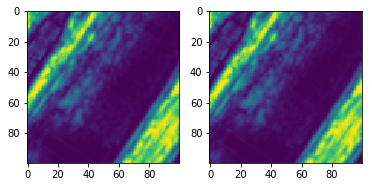

In [30]:
plt.subplot(121)
plt.imshow(image_set[-5]);

plt.subplot(122)
plt.imshow(image_set[-2]);

In [31]:
weights = model.get_weights()

In [32]:
focus_layer = weights[10]
focus_layer.shape

(16,)

In [33]:
hist_indices = []

for i in range(len(weights)):
    x = weights[i]
    if len(x.shape)>1:
        print(x.shape )
        hist_indices+=[i]
        
hist_indices

(8, 8, 1, 16)
(8, 8, 16, 16)
(6, 6, 16, 32)
(6, 6, 32, 32)
(4, 4, 32, 64)
(4, 4, 64, 64)
(2, 2, 64, 128)
(2, 2, 128, 128)
(128, 1)


[4, 6, 12, 14, 20, 22, 28, 30, 32]

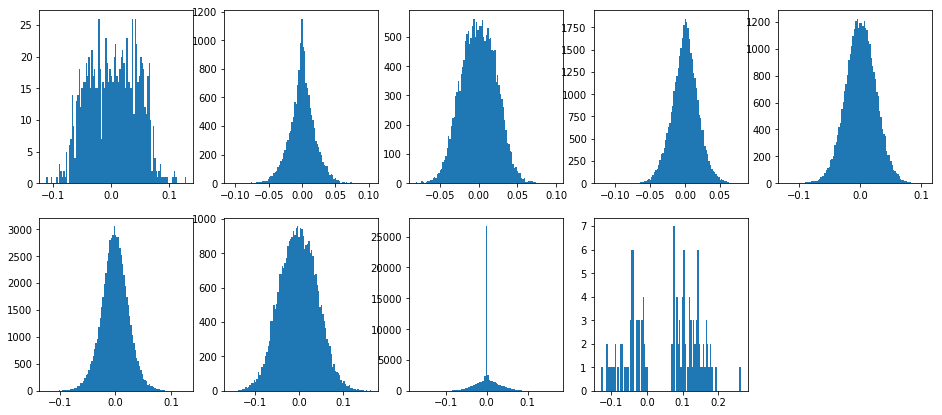

In [34]:
plt.figure(figsize=(16,7))

for i in range(len(hist_indices)):
    
    weight_index = hist_indices[i]
    focus_layer = weights[weight_index]
    
    plt.subplot(2,5,i+1)
    plt.hist(focus_layer.flatten(),bins=100);